In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
import seaborn as sns
from utils import *
# Configurações de visualização
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

# Previsão e avaliação de performance
- Definir como o cross-validation (lembrando que queremos sempre prever 4 passos à frente)
- Avaliar os modelos TSLM e ARIMA nessa previsão
- Calcular erro por horizonte: RMSE e MAE separadamente para h = 1 e h = 4, para ver o quanto o modelo perde precisão conforme se afasta no tempo
- Comparar ambos e um modelo naive
- Plotar erros por horizonte (h) e linhas de previsão para cada janela de treinamento

## Definindo o Cross Validation
Para modelar como prever, utilizaremos a estratégia sugerida em aula de sempre tentar prever 4 passos a frente. Existem algumas decisões de projeto a se tomar as quais são: Como fazer para prever 4 passos a frente?
para isso utiliarei a estratégia de prever o volume para t_h+1 e depois disso usar esse volume previsto para t_h+2 e etc. Os dados de Inv e de Users serão tratados como os mesmos para todos os lags para a simplificação do problema.
Nosso modelo avaliará o erro a partir de cada lag feito. e testa-lo assim para ver o modelo. 

Treinaremos o modelo contra o modelo naive também. 


In [41]:
from abc import ABC, abstractmethod
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX



In [42]:
class NaiveModel(ForecastingStrategy):
    def __init__(self):
        self.last_value = None
        self._name = "Naive Baseline"

    def fit(self, y_train, X_train=None):
        # Pega o último valor
        self.last_value = y_train.iloc[-1]

    def predict(self, steps, X_future=None):
        # Retorna o último valor repetido N vezes
        return np.array([self.last_value] * steps)

    @property
    def name(self):
        return self._name

class ArimaModel(ForecastingStrategy):
    def __init__(self, order, seasonal_order=(0,0,0,0)):
        self.order = order
        self.seasonal_order = seasonal_order
        self.model_fit = None
        self._name = f"ARIMA {order}"

    def fit(self, y_train, X_train=None):
        # É modelado com SARIMAX porque o X entra como as variáveis exógenas (de fora)
        model = SARIMAX(y_train, exog=X_train, order=self.order, 
                        seasonal_order=self.seasonal_order,
                        enforce_stationarity=False, enforce_invertibility=False)
        self.model_fit = model.fit(disp=False)

    def predict(self, steps, X_future=None):
        # Delega a previsão para o objeto treinado
        forecast = self.model_fit.forecast(steps=steps, exog=X_future)
        return forecast.values

    @property
    def name(self):
        return self._name

In [43]:
class TimeSeriesCrossValidator:
    def __init__(self, df, target_col, exog_cols=None):
        self.df = df
        self.target_col = target_col
        self.exog_cols = exog_cols
        
    def _prepare_naive_exog(self, train_exog, steps):
        if self.exog_cols is None:
            return None
        
        last_values = train_exog.iloc[-1]
        # Repete o último valor um número steps de vezes
        return pd.DataFrame([last_values] * steps)

    def validate(self, strategy: ForecastingStrategy, steps_ahead=4, train_ratio=0.7):
        """
        Método para validar dado alguma estratégia
        """
        n = len(self.df)
        start_index = int(n * train_ratio)
        results = []
        
        print(f"--- Iniciando Validação: {strategy.name} ---")
        
        for i in range(start_index, n - steps_ahead + 1):
            # Dividindo temporalmente
            train = self.df.iloc[:i]
            test_future = self.df.iloc[i : i + steps_ahead]
            
            y_train = train[self.target_col]
            X_train = train[self.exog_cols] if self.exog_cols else None
            
            # Preparar Cenário Futuro 
            X_future_naive = self._prepare_naive_exog(X_train, steps_ahead)
            if X_future_naive is not None:
                # Ajuste do index
                X_future_naive.index = test_future.index

            # Fitamos com os dados que temos
            strategy.fit(y_train, X_train)
            # Predizemos para os próximos
            preds = strategy.predict(steps_ahead, X_future_naive)
            
            # Métricas
            for h, prediction in enumerate(preds):
                actual = test_future[self.target_col].iloc[h]
                target_date = test_future.index[h]
                
                results.append({
                    'cutoff_date': train.index[-1],
                    'target_date': target_date,
                    'horizon': h + 1,
                    'model': strategy.name,
                    'prediction': prediction,
                    'actual': actual,
                    'sq_error': (prediction - actual)**2
                })
                    
                
        return pd.DataFrame(results)

In [44]:
class RMSE(MetricStrategy):
    def calculate(self, y_true, y_pred):
        return np.sqrt(np.mean((y_true - y_pred)**2))
    
    @property
    def name(self):
        return "RMSE"

class MAE(MetricStrategy):
    def calculate(self, y_true, y_pred):
        return np.mean(np.abs(y_true - y_pred))
    
    @property
    def name(self):
        return "MAE"

class MAPE(MetricStrategy):
    def calculate(self, y_true, y_pred):
        mask = y_true != 0
        return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    
    @property
    def name(self):
        return "MAPE"

class MetricsEvaluator:
    def __init__(self):
        self.metrics = []
        
    def add_metric(self, metric: MetricStrategy):
        """Adiciona uma métrica à lista de avaliação."""
        self.metrics.append(metric)
        return self
        
    def evaluate(self, results_list):
        """
        Recebe uma lista de DataFrames de resultados crus (prediction vs actual).
        Retorna um DataFrame com TODAS as métricas calculadas.
        """
        consolidated_data = []
        
        for res_df in results_list:
            model_name = res_df['model'].iloc[0]
            
            for horizon, group in res_df.groupby('horizon'):
                y_true = group['actual'].values
                y_pred = group['prediction'].values
                
                row = {
                    'Model': model_name,
                    'Horizon': horizon
                }
                
                # Aplica todas as métricas cadastradas
                for metric in self.metrics:
                    row[metric.name] = metric.calculate(y_true, y_pred)
                    
                consolidated_data.append(row)
                
        return pd.DataFrame(consolidated_data)

In [ ]:
class ResultsVisualizer:
    
    @staticmethod
    def plot_metric_comparison(metrics_df, metric_name):
        """Plota métricas de erro."""
        plt.figure(figsize=(10, 6))
        
        sns.barplot(data=metrics_df, x='Horizon', y=metric_name, hue='Model')
        
        plt.title(f"Comparação de Performance: {metric_name}")
        plt.ylabel(metric_name)
        plt.xlabel("Horizonte (Semanas à frente)")
        plt.grid(True, alpha=0.3, axis='y')
        plt.legend(title='Modelo')
        plt.show()

    @staticmethod
    def plot_continuous(results_df, real_data_df, target_col):
        """Plota apenas a previsão com lag 1 como uma linha única."""
        plt.figure(figsize=(12, 6))
        
        sns.lineplot(data=real_data_df, x=real_data_df.index, y=target_col, 
                     color='black', label='Real', alpha=0.4, linewidth=2)
        
        # Dados previstos
        results_df['target_date'] = pd.to_datetime(results_df['target_date'])
        h1_data = results_df[results_df['horizon'] == 1]
        
        sns.lineplot(data=h1_data, x='target_date', y='prediction', 
                     color='red', label='Previsão Contínua (h=1)')
        
        model_name = results_df['model'].iloc[0]
        plt.title(f"Previsão Contínua (One-Step Ahead) - {model_name}")
        plt.grid(True, alpha=0.2)
        plt.show()

    @staticmethod
    def plot_spaghetti(results_df, real_data_df, target_col):
        """Plota todas as projeções de 4 passos."""
        plt.figure(figsize=(12, 6))
        
        # Dados reais
        sns.lineplot(data=real_data_df, x=real_data_df.index, y=target_col, 
                     color='black', label='Real', alpha=0.3, linewidth=2)
        
        model_name = results_df['model'].iloc[0]
        
        results_df['target_date'] = pd.to_datetime(results_df['target_date'])

        sns.lineplot(
            data=results_df, 
            x='target_date', 
            y='prediction', 
            hue=None,
            units='cutoff_date',
            estimator=None,
            color='blue',
            alpha=0.3,
            linewidth=1,
            legend=None
        )
        
        plt.plot([], [], color='blue', label='Projeções (4 passos)')
        
        plt.title(f"Spaghetti Plot (Todas as Projeções) - {model_name}")
        if not results_df.empty:
            plt.xlim(results_df['target_date'].min(), results_df['target_date'].max())
            
        plt.legend()
        plt.grid(True, alpha=0.2)
        plt.show()

In [60]:
df = pd.read_csv('data_updated.csv')
df['week'] = pd.to_datetime(df['week'])
df = df.set_index('week').sort_index().asfreq('W-MON')

validator = TimeSeriesCrossValidator(df, target_col='volume', exog_cols=['inv', 'users'])

strategy_naive = NaiveModel()
strategy_arima = ArimaModel(order=(1,0,0), seasonal_order=(0,0,0,0))

results_naive = validator.validate(strategy_naive)
results_arima = validator.validate(strategy_arima)

evaluator = MetricsEvaluator()

evaluator.add_metric(RMSE())
evaluator.add_metric(MAE())
evaluator.add_metric(MAPE()) 

df_metrics = evaluator.evaluate([results_naive, results_arima])

viz = ResultsVisualizer()

df_metrics


--- Iniciando Validação: Naive Baseline ---
--- Iniciando Validação: ARIMA (1, 0, 0) ---


,Model,Horizon,RMSE,MAE,MAPE
0,Naive Baseline,1,1.856846,1.347111,14.210985
1,Naive Baseline,2,2.351746,1.803778,18.843497
2,Naive Baseline,3,2.674258,2.135556,21.422333
3,Naive Baseline,4,2.778080,2.126222,20.488605
4,"ARIMA (1, 0, 0)",1,1.913192,1.365065,14.435912
5,"ARIMA (1, 0, 0)",2,2.468349,1.904749,19.654206
6,"ARIMA (1, 0, 0)",3,2.767277,2.162401,22.063011
7,"ARIMA (1, 0, 0)",4,2.818569,2.198654,21.401061


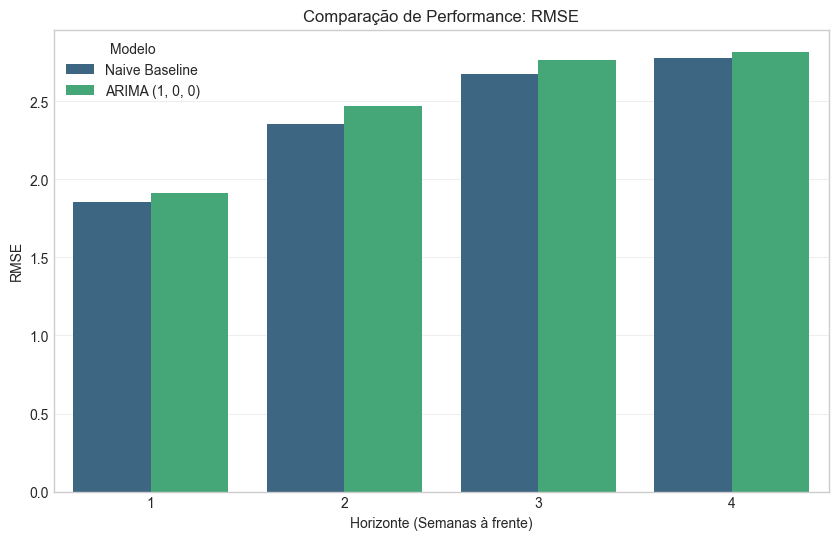

In [61]:

viz.plot_metric_comparison(df_metrics, 'RMSE')

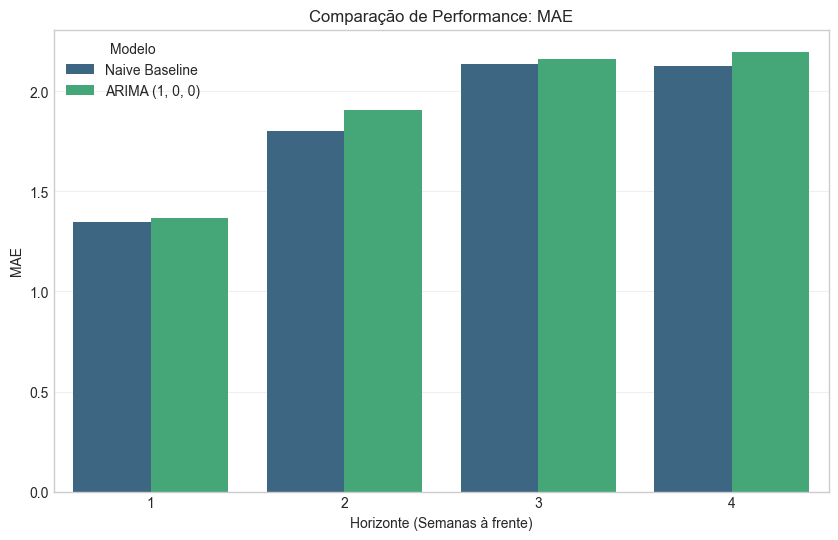

In [62]:
viz.plot_metric_comparison(df_metrics, 'MAE')

In [63]:
results_arima

,cutoff_date,target_date,horizon,model,prediction,actual,sq_error
0,2024-11-25,2024-12-02,1,"ARIMA (1, 0, 0)",3.415462,4.08,0.441611
1,2024-11-25,2024-12-09,2,"ARIMA (1, 0, 0)",3.391125,3.25,0.019916
2,2024-11-25,2024-12-16,3,"ARIMA (1, 0, 0)",3.366987,2.92,0.199797
3,2024-11-25,2024-12-23,4,"ARIMA (1, 0, 0)",3.343047,2.47,0.762210
4,2024-12-02,2024-12-09,1,"ARIMA (1, 0, 0)",4.058870,3.25,0.654271
...,...,...,...,...,...,...,...
175,2025-09-22,2025-10-20,4,"ARIMA (1, 0, 0)",22.107302,24.52,5.821110
176,2025-09-29,2025-10-06,1,"ARIMA (1, 0, 0)",20.879416,14.50,40.696953
177,2025-09-29,2025-10-13,2,"ARIMA (1, 0, 0)",21.444713,17.89,12.635986
178,2025-09-29,2025-10-20,3,"ARIMA (1, 0, 0)",22.026349,24.52,6.218294


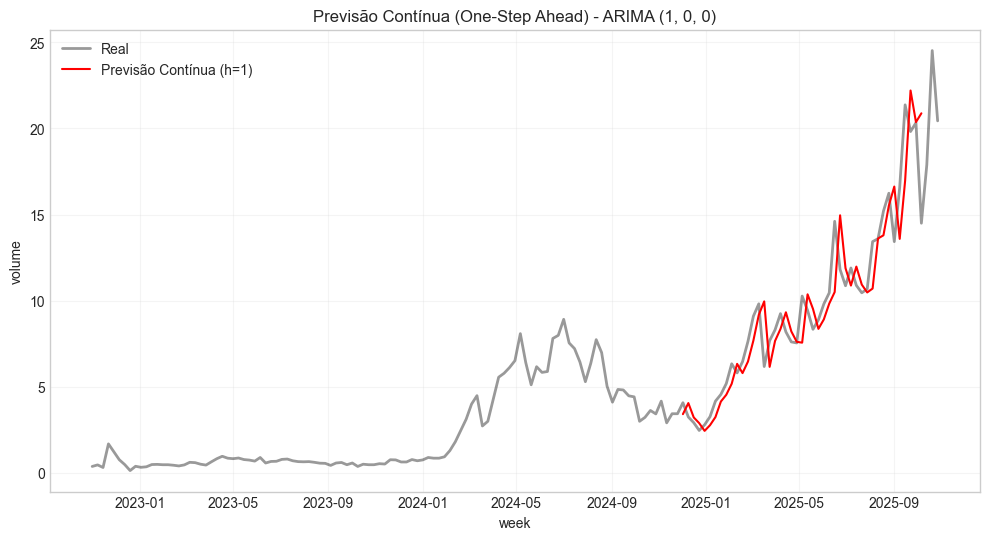

In [67]:
viz.plot_continuous(results_arima, df,'volume')